# Chladni plates and spherical harmonics

Eigenmodes of the wave equation on a bounded medium give standing-wave
patterns whose nodal lines/surfaces fall on the points where the field is
zero. `harmonic_geometry` exposes rectangular, circular, polygonal, and
3-D box plates, plus the spherical-harmonic basis on a sphere — the
closed-surface analogue of a Chladni plate.

This notebook reproduces the plate and sphere figures from the report.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Rectangular plate — pure modes

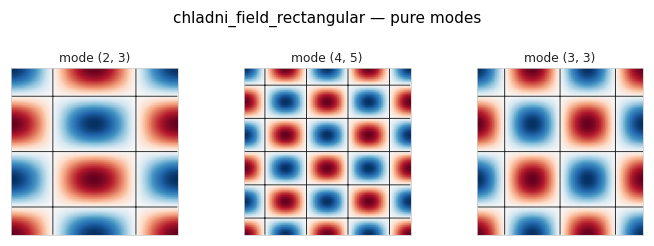

In [2]:
from biotuner.harmonic_geometry import chladni_field_rectangular

modes = [(2, 3), (4, 5), (3, 3)]
geoms = [chladni_field_rectangular([m], resolution=257) for m in modes]
plotting.gallery(geoms, titles=[f"mode {m}" for m in modes], n_cols=3,
                 suptitle="chladni_field_rectangular — pure modes");


### Superposition of modes

Summing several modes with prescribed amplitudes and phases is what a real
plate does under a chord-shaped excitation.

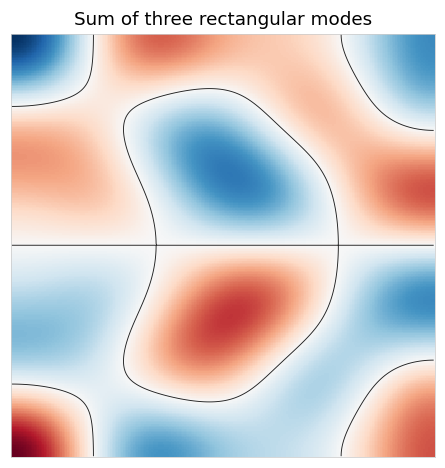

In [3]:
g = chladni_field_rectangular(
    modes=[(2, 3), (3, 5), (4, 1)],
    amps=[1.0, 0.6, 0.4],
    phases=[0.0, np.pi/3, np.pi/7],
    resolution=257,
)
fig, ax = plotting.plot_geometry(g)
ax.set_title("Sum of three rectangular modes");


## Circular plate (Bessel modes)

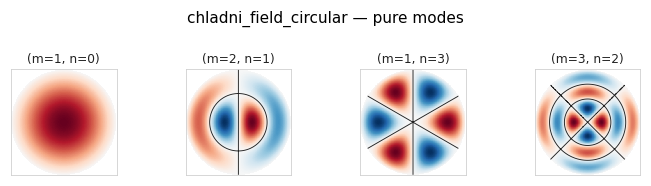

In [4]:
from biotuner.harmonic_geometry import chladni_field_circular

cases = [([1], [0], "(m=1, n=0)"),
         ([2], [1], "(m=2, n=1)"),
         ([1], [3], "(m=1, n=3)"),
         ([3], [2], "(m=3, n=2)")]
geoms  = [chladni_field_circular(mr, ma, R=1.0, resolution=257) for mr, ma, _ in cases]
titles = [lab for _, _, lab in cases]
plotting.gallery(geoms, titles=titles, n_cols=4,
                 suptitle="chladni_field_circular — pure modes");


## Polygonal plate (finite-difference)

For arbitrary convex polygons the eigenproblem is solved on a finite
difference mesh.

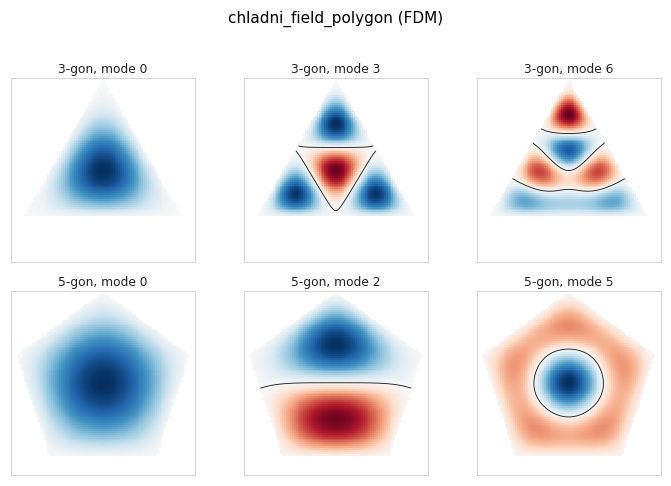

In [5]:
from biotuner.harmonic_geometry import chladni_field_polygon

cases = [(3, 0), (3, 3), (3, 6), (5, 0), (5, 2), (5, 5)]
geoms = [chladni_field_polygon([m], n_sides=ns, resolution=96)
         for ns, m in cases]
titles = [f"{ns}-gon, mode {m}" for ns, m in cases]
plotting.gallery(geoms, titles=titles, n_cols=3,
                 draw_kwargs={"show_nodal": True},
                 suptitle="chladni_field_polygon (FDM)");


## From a chord input — `chladni_from_input`

`chladni_from_input` ties a `HarmonicInput` chord to a plate: each ratio
is mapped to a 2-D or 3-D mode index, the modes are summed, and the result
is returned as a `field_2d`/`field_3d` GeometryData.

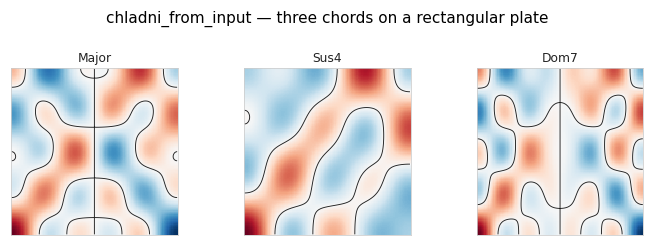

In [6]:
from biotuner.harmonic_geometry import chladni_from_input

chords = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2),
                                    Fraction(7, 4)]),
}
geoms = [chladni_from_input(c, plate="rectangular",
                             plate_kwargs={"resolution": 129})
         for c in chords.values()]
plotting.gallery(geoms, titles=list(chords.keys()), n_cols=3,
                 suptitle="chladni_from_input — three chords on a rectangular plate");


## Spherical harmonics — closed-surface eigenmodes

`single_spherical_harmonic` and `spherical_harmonic_field` produce the
`(l, m)` eigenmodes of the Laplacian on the unit sphere. The plot below
shows three pure modes rendered as colour on the sphere surface.

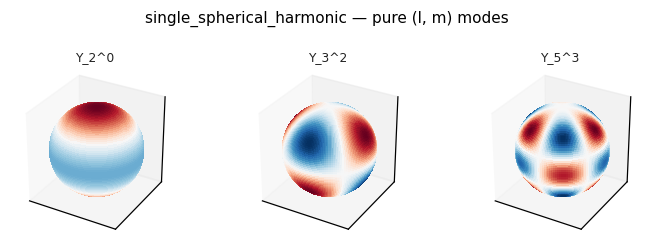

In [7]:
from biotuner.harmonic_geometry import single_spherical_harmonic

cases = [(2, 0), (3, 2), (5, 3)]
geoms  = [single_spherical_harmonic(l, m, n_theta=80, n_phi=160)
          for l, m in cases]
titles = [f"Y_{l}^{m}" for l, m in cases]
plotting.gallery(geoms, titles=titles, n_cols=3,
                 suptitle="single_spherical_harmonic — pure (l, m) modes");


### Chord on a sphere

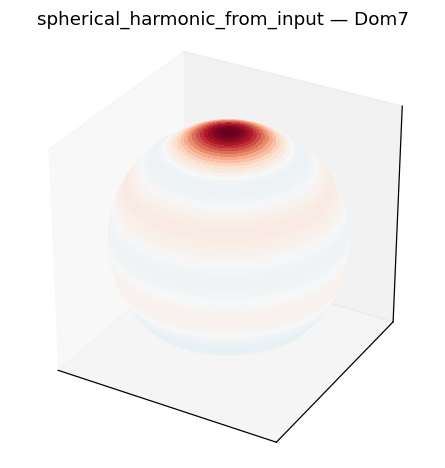

In [8]:
from biotuner.harmonic_geometry import spherical_harmonic_from_input

dom7 = HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                              Fraction(3, 2), Fraction(7, 4)])
g = spherical_harmonic_from_input(dom7, n_theta=96, n_phi=192)
fig, ax = plotting.plot_geometry(g)
ax.set_title("spherical_harmonic_from_input — Dom7");
